In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline

from labs.the_capacitor.calculations.charge import calculate_charge
from labs.the_capacitor.calculations.strength import ElectricFieldStrength
from labs.the_capacitor.model import Capacitor, Plate
from tests.the_capacitor.util import extract_central_area


def reshape_to_rectangle(data: np.ndarray, capacitor: Capacitor) -> np.ndarray:
    return data.reshape(
        capacitor.lower_plate.length_chunk_count, capacitor.lower_plate.width_chunk_count
    )


def analyze_capacitor(side: int, distance: float) -> None:
    capacitor = Capacitor(
        upper_plate=Plate(length=side, width=side, chunk_side=1.0),
        lower_plate=Plate(length=side, width=side, chunk_side=1.0),
        distance=distance,
        voltage=2.0,
    )
    charge = calculate_charge(capacitor)
    new_capacitor, lower_charge, upper_charge = extract_central_area(capacitor, charge)
    print(
        "Charges on center area of both plates",
        float(sum(lower_charge)),
        float(sum(upper_charge)),
        float(sum(lower_charge) / sum(upper_charge)),
    )

    print("############################### Charge Distribution ###############################")

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(
        reshape_to_rectangle(charge[: capacitor.lower_plate.chunk_count], capacitor),
        cmap="coolwarm",
        ax=ax1,
    )
    ax1.set_title("Lower Plate Charge")
    sns.heatmap(
        reshape_to_rectangle(charge[capacitor.lower_plate.chunk_count :], capacitor),
        cmap="coolwarm",
        ax=ax2,
    )
    ax2.set_title("Upper Plate Charge")
    plt.tight_layout()
    plt.show()

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(reshape_to_rectangle(lower_charge, new_capacitor), cmap="coolwarm", ax=ax1)
    ax1.set_title("Lower Center Plate Charge")
    sns.heatmap(reshape_to_rectangle(upper_charge, new_capacitor), cmap="coolwarm", ax=ax2)
    ax2.set_title("Upper Center Plate Charge")
    plt.tight_layout()
    plt.show()

    print("############################### Electric Field Strength ###############################")

    field = ElectricFieldStrength(capacitor, charge)
    grid = capacitor.chunks_vector[: capacitor.lower_plate.chunk_count] + np.array([[0, 0, 0.25]])
    p = np.array([field(point) for point in grid])
    result = (p[:, 0] + p[:, 1]) / p[:, 2]

    center_field = ElectricFieldStrength(
        new_capacitor, np.concatenate([lower_charge, upper_charge])
    )
    grid = new_capacitor.chunks_vector[: new_capacitor.lower_plate.chunk_count] + np.array(
        [[0, 0, 0.25]]
    )
    p = np.array([center_field(point) for point in grid])
    center_result = (p[:, 0] + p[:, 1]) / p[:, 2]

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(reshape_to_rectangle(result, capacitor), cmap="coolwarm", ax=ax1)
    ax1.set_title("Field Vertical Component")
    sns.heatmap(reshape_to_rectangle(center_result, new_capacitor), cmap="coolwarm", ax=ax2)
    ax2.set_title("Center Field Vertical Component")
    plt.tight_layout()
    plt.show()

Charges on center area of both plates 900.7220485242391 -899.2825613315401 -1.0016007062236008
############################### Charge Distribution ###############################


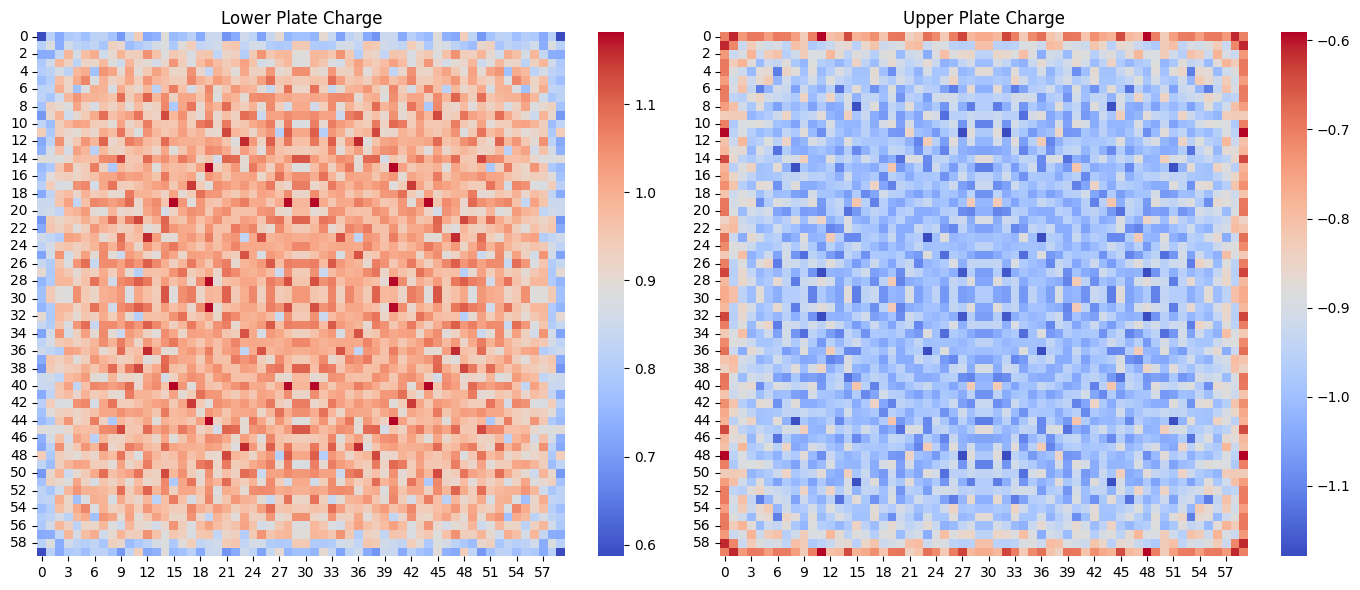

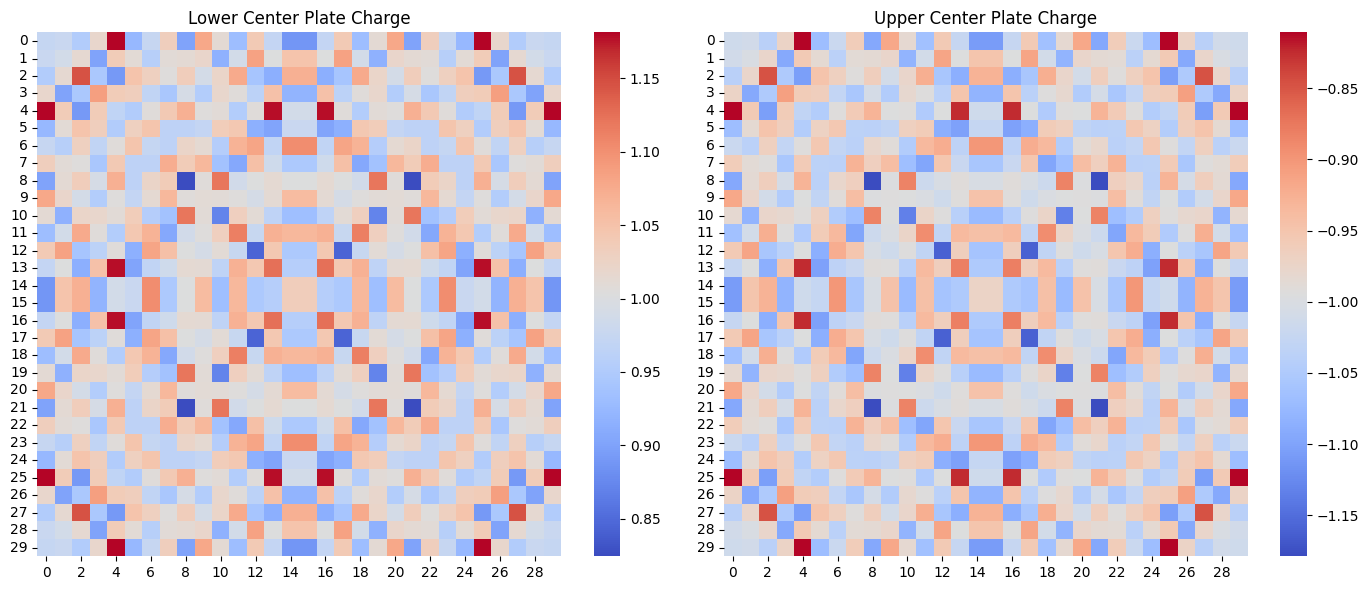

############################### Electric Field Strength ###############################


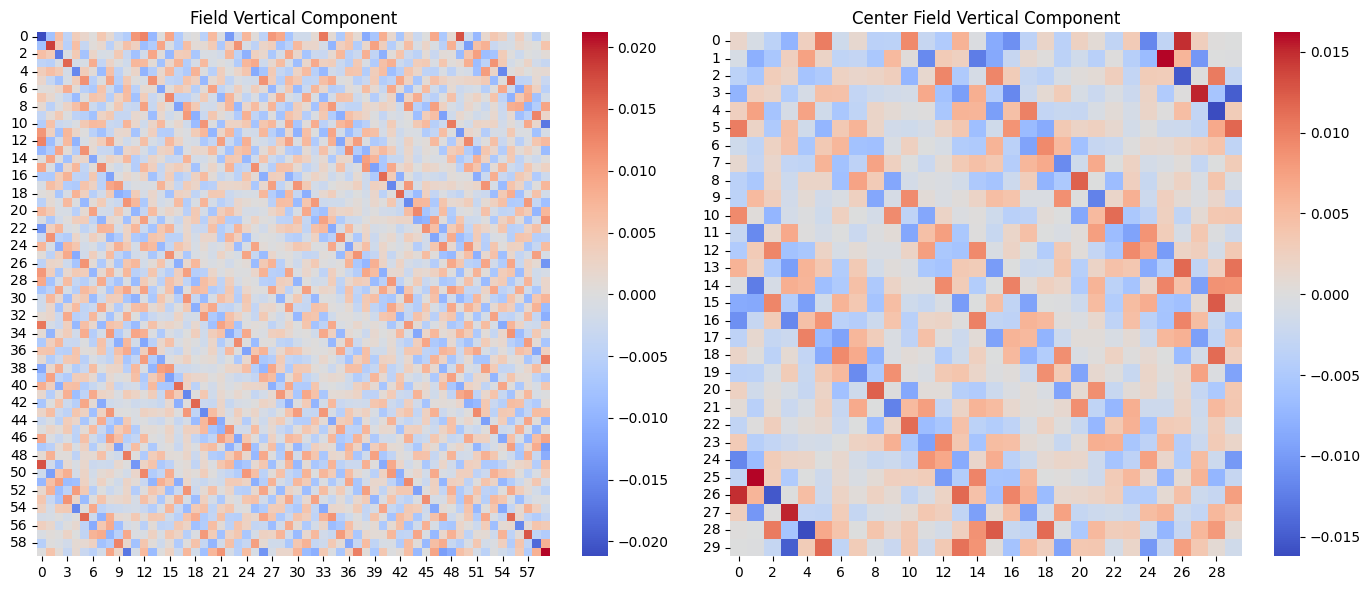

In [72]:
analyze_capacitor(60, 0.5)

Charges on center area of both plates -140.49422194883078 138.55816112777487 -1.0139729107639537
############################### Charge Distribution ###############################


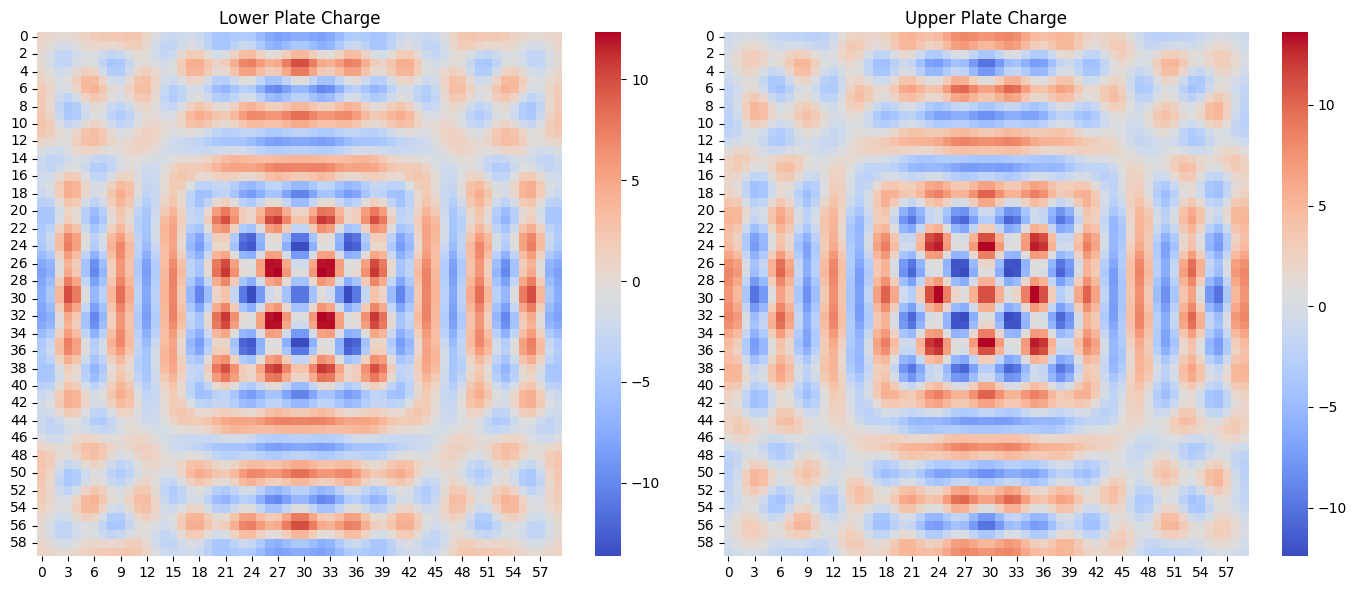

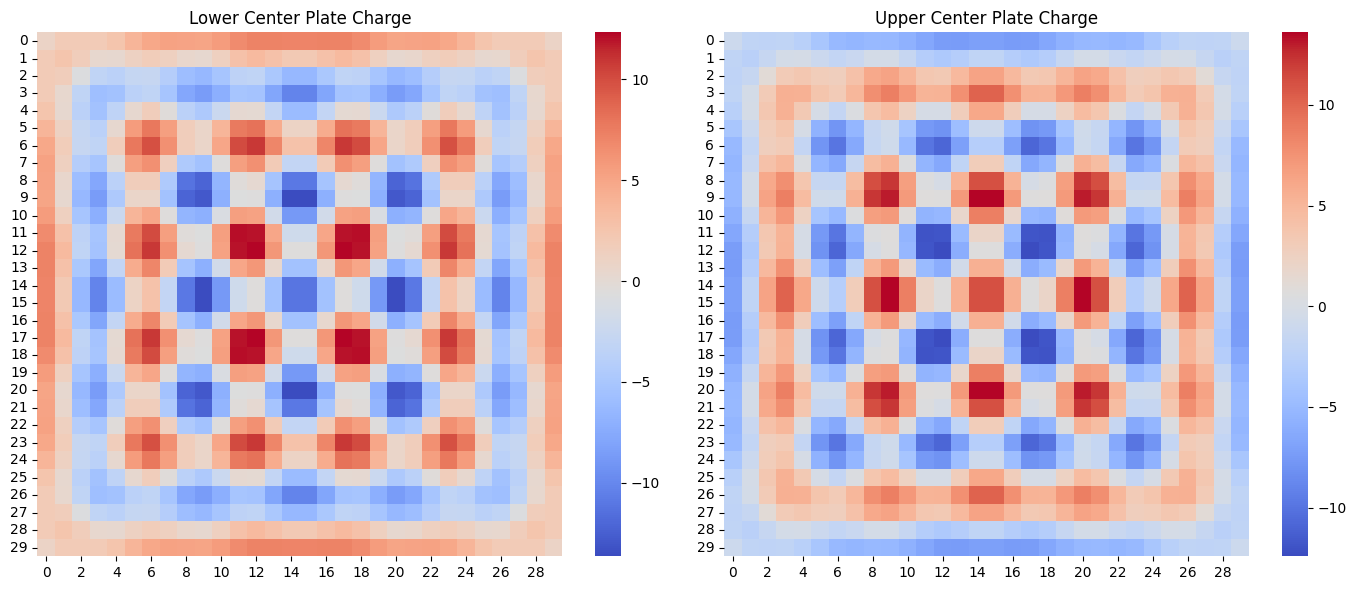

############################### Electric Field Strength ###############################


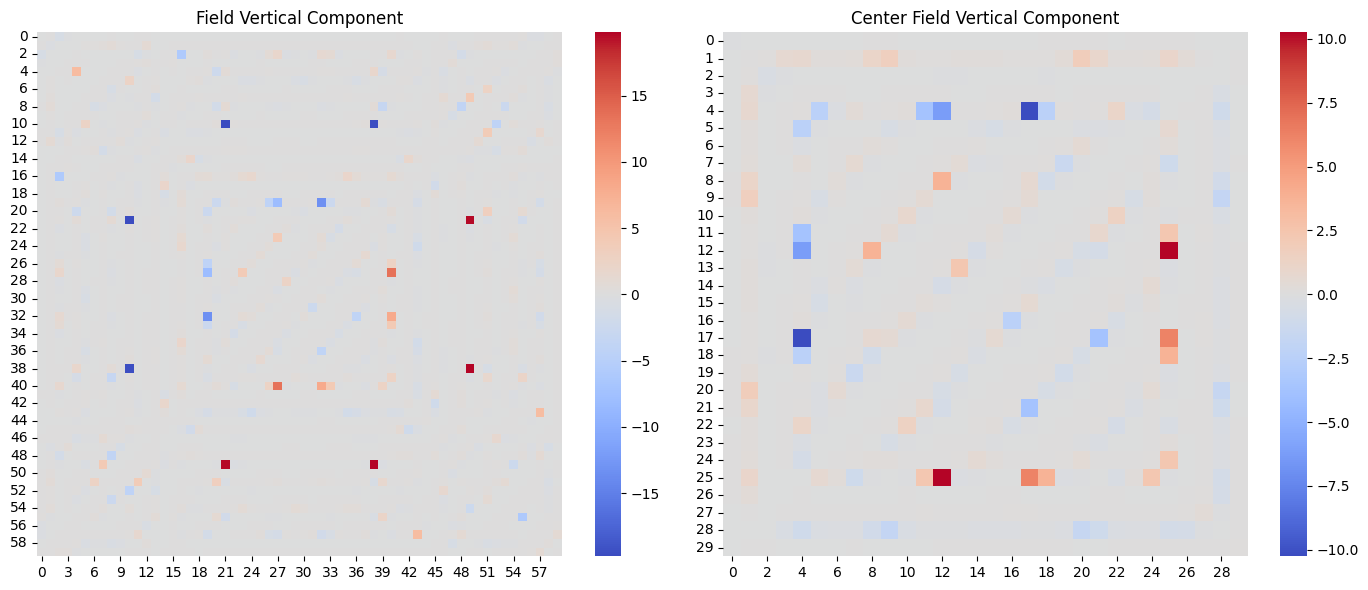

In [73]:
analyze_capacitor(60, 1)

Charges on center area of both plates -4.138541947686513 6.630573981656043 -0.6241604360551719
############################### Charge Distribution ###############################


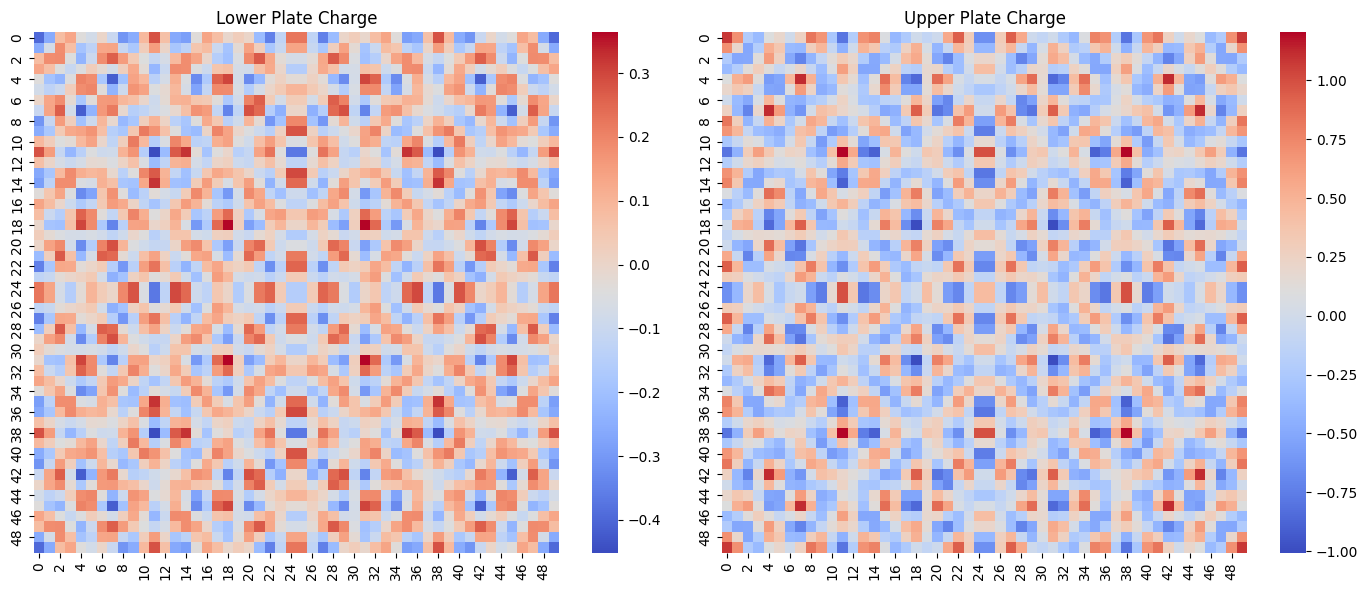

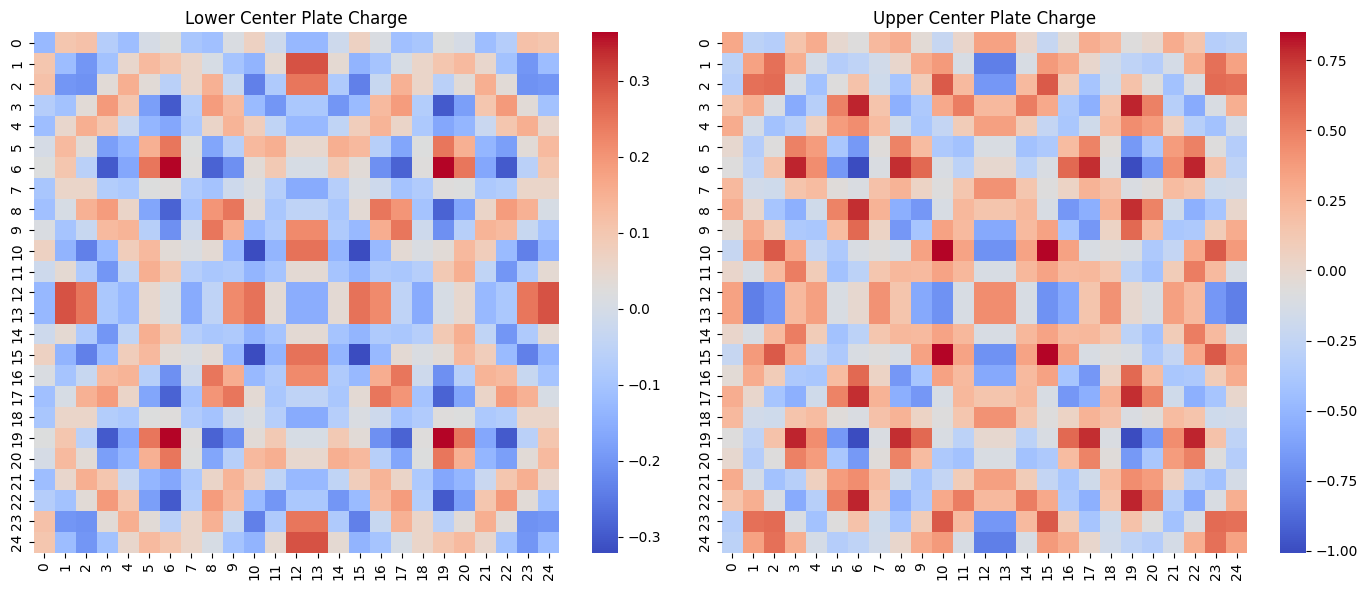

############################### Electric Field Strength ###############################


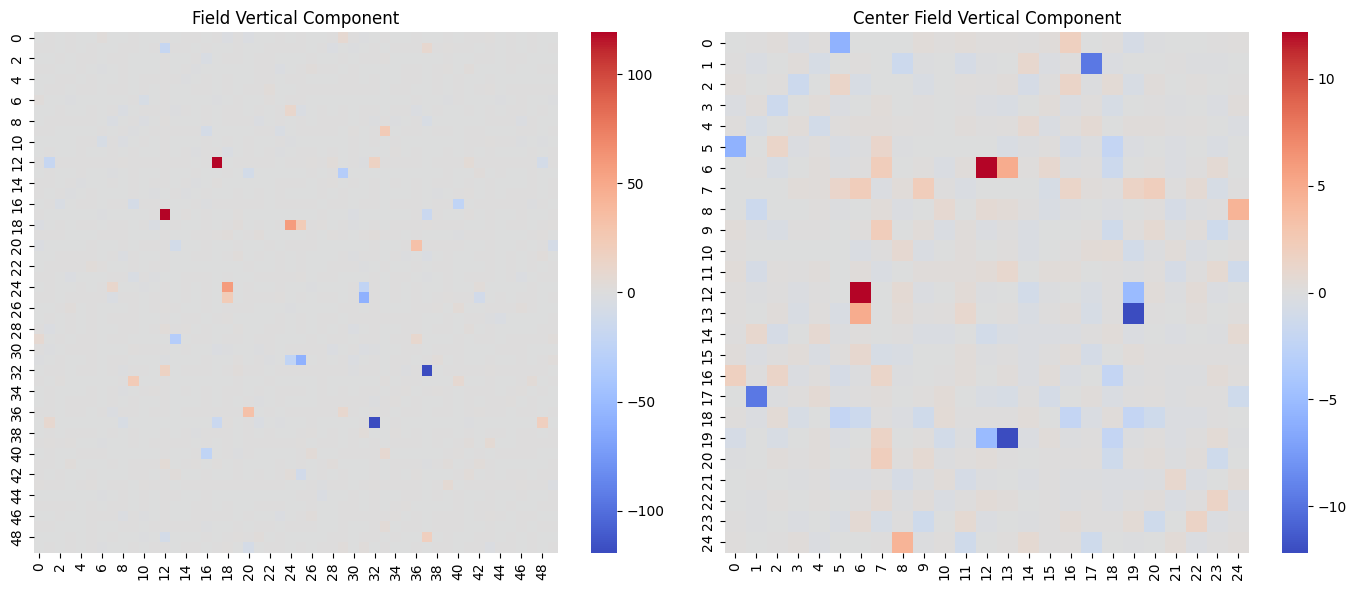

In [75]:
analyze_capacitor(50, 25)